In [24]:
from src.preprocessing.preprocessing import processor
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences
from src.postprocessing.inference import FloodClassifier
from src.postprocessing.postprocessing import PostProcessor
from datetime import datetime

SITE_ID = "06820500"


In [25]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30:v0",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
    "sites": [SITE_ID],
}
pcr = processor(config)
pcr.pull_wandb()


wandb: Downloading large artifact 'flood-dataset-top30:v0', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.2 (844.1MB/s)


Starting preprocessing: 141,711 rows, 31 columns
After lag null removal: 135,797 rows, 28 features
Splitting by time...
Train: 108,637 | Val: 13,580 | Test: 13,580
Scaling features and targets...
Scaling complete.


In [26]:
classifier = FloodClassifier()
_tmp = LSTMModel()
asymmetric_mse = _tmp._loss()

model = LSTMModel.load_model(
    "lstm_model_2xloss.keras",
    custom_objects={"asymmetric_mse": asymmetric_mse}
)

In [27]:
inference_df = pcr.prep_inference(wandb_config={
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "start_date": "2021-6-21",                 
    "end_date":   "2021-6-28",
    "frequency":  "hourly",                     
})

wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.1 (1161.5MB/s)


In [28]:
import numpy as np
import polars as pl
from datetime import timedelta
pl.Config.set_tbl_rows(50)
X_data, _, train_site_ids = create_sequences(inference_df, None, 72)

mask = np.array(train_site_ids) == "06820500"
X_site = X_data[mask]
site_ids = np.array(train_site_ids)[mask]

preds = model.predict(X_site)
unscaled_preds = pcr.unscale(preds, site_ids)
results = classifier.classify(unscaled_preds, site_ids)

# forecast_at = end of the 72h window + 24h ahead
timestamps = [
    t + timedelta(hours=24)
    for t in inference_df.filter(pl.col("site_id") == "06820500")["observation_hour"][72:].to_list()
]
df = pl.DataFrame({
    "forecast_at": timestamps,
    "predicted_cfs": unscaled_preds.tolist(),
    **{rp: [r[rp] for r in results] for rp in results[0]},
})
df


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


forecast_at,predicted_cfs,Q2_cfs,Q5_cfs,Q10_cfs,Q25_cfs,Q50_cfs,Q100_cfs
datetime[μs],list[f64],bool,bool,bool,bool,bool,bool
2021-06-25 00:00:00,[813.801835],false,false,false,false,false,false
2021-06-25 01:00:00,[816.578034],false,false,false,false,false,false
2021-06-25 02:00:00,[825.515017],false,false,false,false,false,false
2021-06-25 03:00:00,[833.367135],false,false,false,false,false,false
2021-06-25 04:00:00,[846.942755],false,false,false,false,false,false
2021-06-25 05:00:00,[857.954298],false,false,false,false,false,false
2021-06-25 06:00:00,[877.199909],false,false,false,false,false,false
2021-06-25 07:00:00,[900.638123],false,false,false,false,false,false
2021-06-25 08:00:00,[889.252743],false,false,false,false,false,false


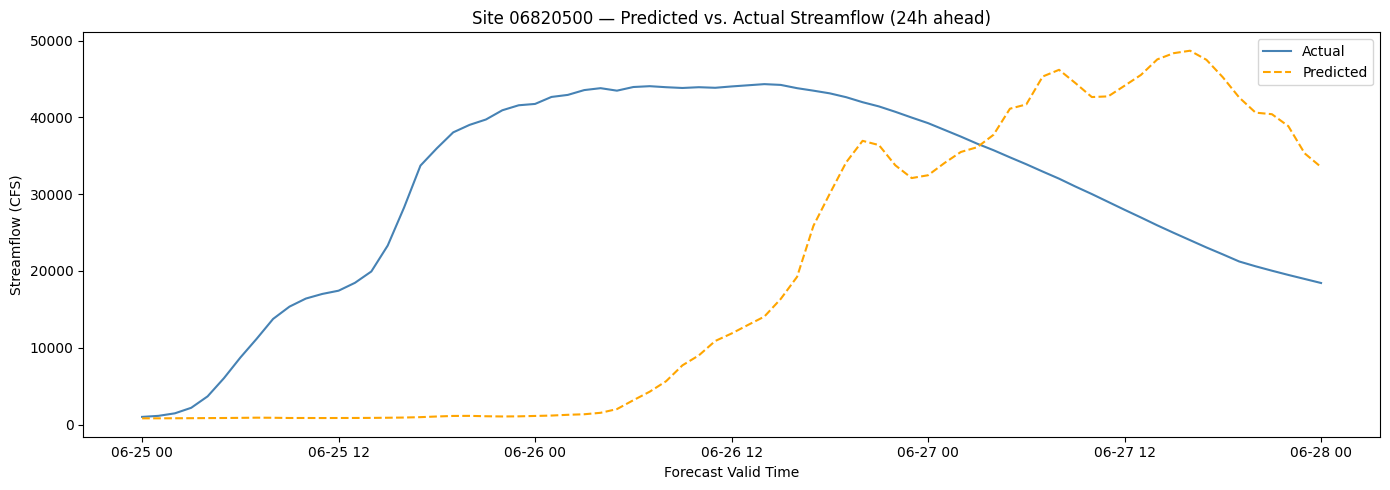

In [29]:
import matplotlib.pyplot as plt

site_df = inference_df.filter(pl.col("site_id") == SITE_ID)

actuals_raw = site_df["streamflow_cfs_mean"][72 + 24:].to_list()
actual_site_ids = np.array([SITE_ID] * len(actuals_raw))
unscaled_actuals = pcr.unscale(np.array(actuals_raw).reshape(-1, 1), actual_site_ids)

n = len(actuals_raw)
unscaled_preds_aligned = unscaled_preds[:n]
timestamps_aligned = timestamps[:n]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(timestamps_aligned, unscaled_actuals.flatten(), label="Actual", color="steelblue")
ax.plot(timestamps_aligned, unscaled_preds_aligned.flatten(), label="Predicted", color="orange", linestyle="--")
ax.set_title(f"Site {SITE_ID} — Predicted vs. Actual Streamflow (24h ahead)")
ax.set_xlabel("Forecast Valid Time")
ax.set_ylabel("Streamflow (CFS)")
ax.legend()
plt.tight_layout()
plt.show()

Event sequences: 49
Computing SHAP values via KernelSHAP (nsamples=200)...


  0%|          | 0/49 [00:00<?, ?it/s]

Done.
Excluding from plots: streamflow_cfs_min, streamflow_cfs_max


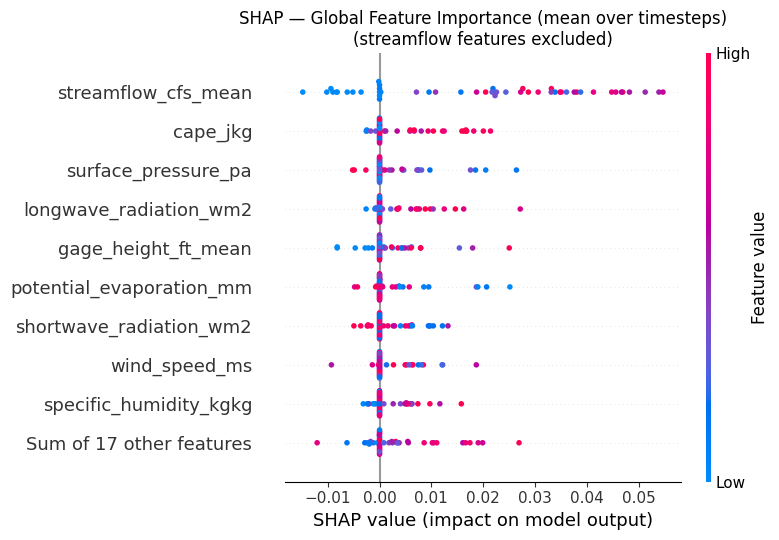

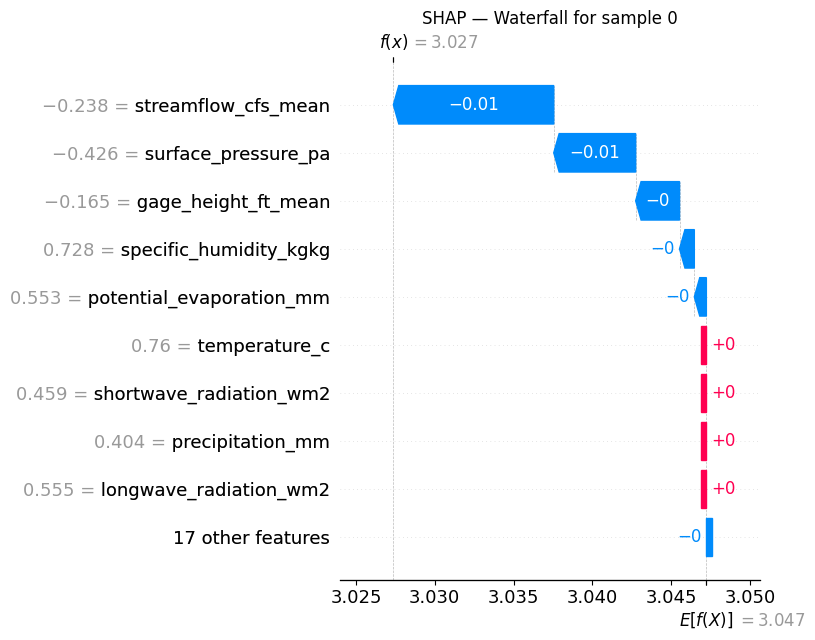

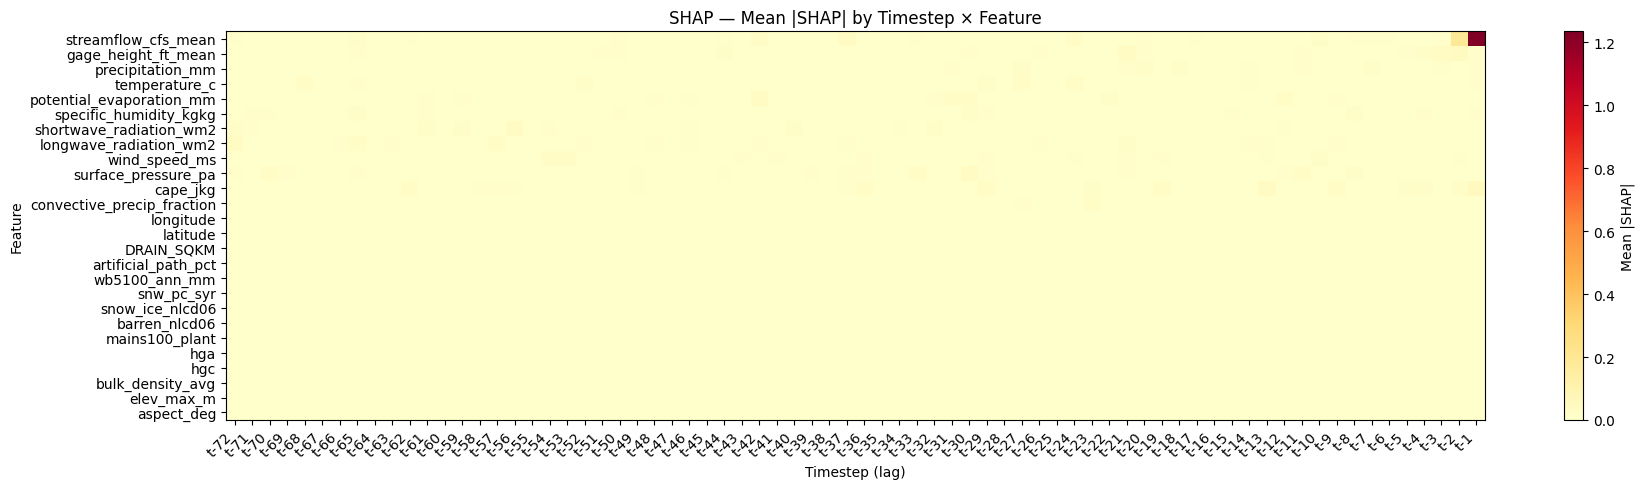

In [30]:
event_start = datetime(2021, 6, 26)
event_end   = datetime(2021, 6, 28)

event_mask = [event_start <= t <= event_end for t in timestamps]
X_event = X_site[np.array(event_mask)]
event_timestamps = [t for t, m in zip(timestamps, event_mask) if m]

print(f"Event sequences: {len(X_event)}")

pp = PostProcessor(
    model=model,
    X_test=X_event,
    y_test=np.zeros(len(X_event)),
    site_ids=np.array([SITE_ID] * len(X_event)),
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES
)

shap_values = pp.compute_shap(
    background_size=min(20, len(X_event) - 1),
    max_explain_samples=len(X_event),
    nsamples=200,
    exclude_features=["streamflow_cfs_min", "streamflow_cfs_max"]
)